In [23]:
! pip install --upgrade nbformat ipykernel

  Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)



[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
BASE_DIR = Path().resolve().parent   # goes from notebooks → project root
file_path = BASE_DIR / "data" / "auto-mpg.data"

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None,
    na_values="?"
)
df.columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [3]:
print("Shape:", df.shape)

df.head()

Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 34.4 KB


In [5]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [6]:
df.dropna(inplace=True)

print("Missing Values Removed ✅")

Missing Values Removed ✅


In [7]:
origin_map = {
    1: "USA",
    2: "Europe",
    3: "Japan"
}

df["origin"] = df["origin"].map(origin_map)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA,ford torino


In [8]:
df.describe().round(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.00,392.00,392.00,392.00,392.00,392.00,392.00
mean,23.45,5.47,194.41,104.47,2977.58,15.54,75.98
std,7.81,1.71,104.64,38.49,849.40,2.76,3.68
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00
25%,17.00,4.00,105.00,75.00,2225.25,13.78,73.00
50%,22.75,4.00,151.00,93.50,2803.50,15.50,76.00
75%,29.00,8.00,275.75,126.00,3614.75,17.02,79.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00


In [9]:
df["power_to_weight"] = (
    df["horsepower"] / df["weight"]
)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,power_to_weight
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA,chevrolet chevelle malibu,0.037100
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA,buick skylark 320,0.044679
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA,plymouth satellite,0.043655
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA,amc rebel sst,0.043694
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA,ford torino,0.040591


In [10]:
avg_mpg = round(df["mpg"].mean(), 2)
max_mpg = df["mpg"].max()
min_mpg = df["mpg"].min()

avg_hp = round(df["horsepower"].mean(), 2)

total_vehicles = len(df)

print("Average MPG:", avg_mpg)
print("Maximum MPG:", max_mpg)
print("Minimum MPG:", min_mpg)
print("Average Horsepower:", avg_hp)
print("Total Vehicles:", total_vehicles)

Average MPG: 23.45
Maximum MPG: 46.6
Minimum MPG: 9.0
Average Horsepower: 104.47
Total Vehicles: 392


In [11]:
mpg_year = (
    df.groupby("model_year")["mpg"]
    .mean()
)

mpg_year

model_year
70    17.689655
71    21.111111
72    18.714286
73    17.100000
74    22.769231
75    20.266667
76    21.573529
77    23.375000
78    24.061111
79    25.093103
80    33.803704
81    30.185714
82    32.000000
Name: mpg, dtype: float64

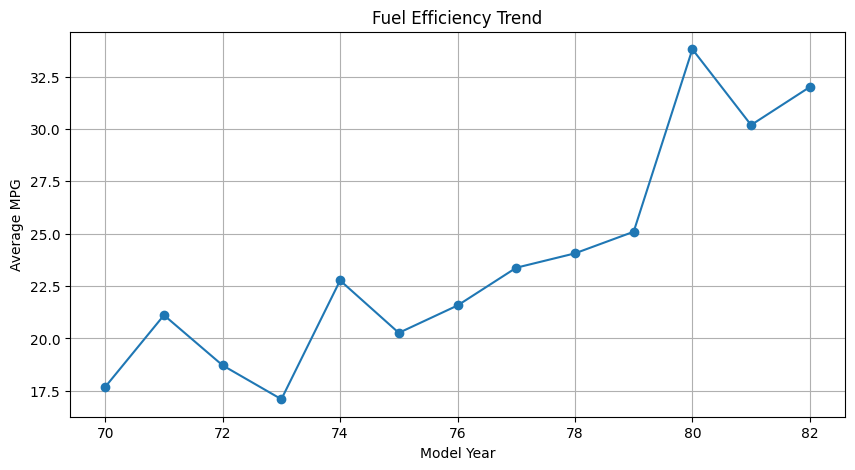

In [12]:
plt.figure(figsize=(10, 5))

mpg_year.plot(kind="line", marker="o")

plt.title("Fuel Efficiency Trend")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")

plt.grid(True)

plt.show()

In [13]:
mpg_origin = (
    df.groupby("origin")["mpg"]
    .mean()
    .reset_index()
)

fig = px.bar(
    mpg_origin,
    x="origin",
    y="mpg",
    text="mpg",
    title="Average MPG by Origin"
)

fig.show()

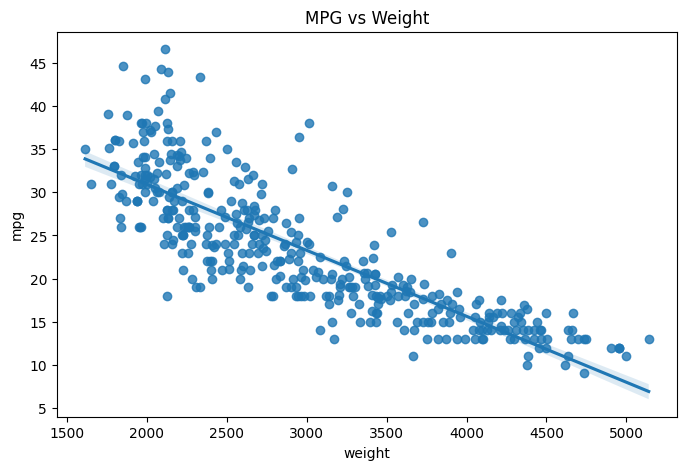

In [14]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="weight",
    y="mpg"
)

plt.title("MPG vs Weight")

plt.show()

In [15]:
fig = px.scatter(
    df,
    x="horsepower",
    y="mpg",
    color="origin",
    trendline="ols",
    title="MPG vs Horsepower"
)

fig.show()

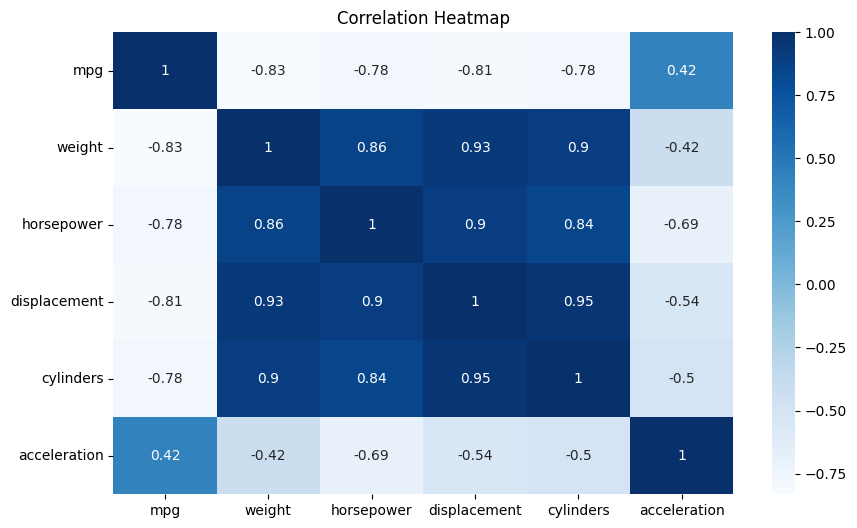

In [16]:
corr = df[
    [
        "mpg",
        "weight",
        "horsepower",
        "displacement",
        "cylinders",
        "acceleration"
    ]
].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

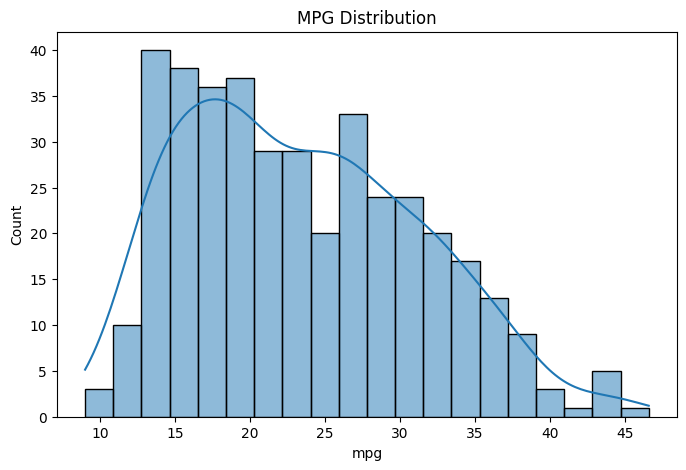

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["mpg"],
    bins=20,
    kde=True
)

plt.title("MPG Distribution")

plt.show()

In [18]:
market_share = (
    df["origin"]
    .value_counts(normalize=True) * 100
)

market_share

origin
USA       62.500000
Japan     20.153061
Europe    17.346939
Name: proportion, dtype: float64

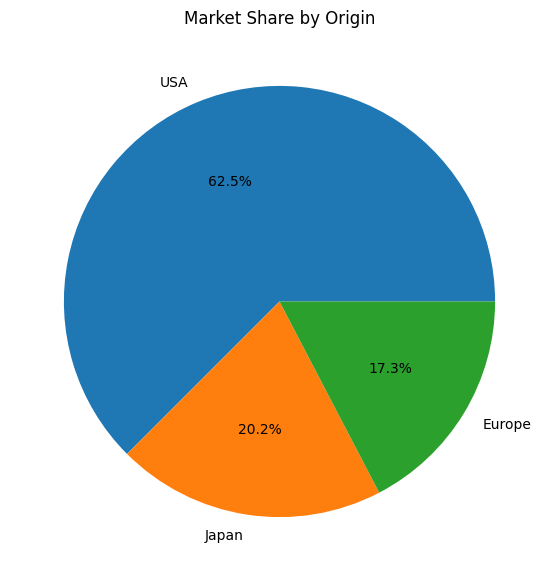

In [19]:
plt.figure(figsize=(7, 7))

market_share.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Market Share by Origin")

plt.ylabel("")

plt.show()

In [20]:
print("Business Insights")

print("- Fuel efficiency improved over years.")
print("- Japan vehicles show better MPG.")
print("- Higher horsepower reduces fuel efficiency.")
print("- Weight negatively impacts MPG.")
print("- Smaller engines provide better mileage.")

Business Insights
- Fuel efficiency improved over years.
- Japan vehicles show better MPG.
- Higher horsepower reduces fuel efficiency.
- Weight negatively impacts MPG.
- Smaller engines provide better mileage.


In [21]:
df.to_csv(
    "../data/cleaned_auto_mpg.csv",
    index=False
)

print("Cleaned Dataset Saved ✅")

Cleaned Dataset Saved ✅


In [22]:
print("""
Project Completed Successfully 🚀

Technologies Used:
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

Project Type:
Business Intelligence Dashboard & Data Analytics
""")


Project Completed Successfully 🚀

Technologies Used:
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly

Project Type:
Business Intelligence Dashboard & Data Analytics

